## Cell 1. Install external tools

BLAST+ is the only external dependency. The NCBI `datasets` CLI handles genome
downloads.

In [1]:
!apt-get -qq update > /dev/null
!apt-get -qq install -y ncbi-blast+ > /dev/null
!tblastn -version | head -1

!curl -sSL -o /usr/local/bin/datasets \
    https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/v2/linux-amd64/datasets
!chmod +x /usr/local/bin/datasets
!datasets --version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
tblastn: 2.12.0+
datasets version: 18.37.0


## Cell 2. Python packages

`xgboost` is optional — the trainer falls back to RandomForest if it is absent.

In [2]:
!pip -q install xgboost biopython
import numpy, pandas, sklearn
print("numpy", numpy.__version__, "| pandas", pandas.__version__,
      "| sklearn", sklearn.__version__)
try:
    import xgboost; print("xgboost", xgboost.__version__)
except ImportError:
    print("xgboost missing - RandomForest fallback will be used")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.1 MB/s eta 0:00:00
numpy 2.1.3 | pandas 2.2.3 | sklearn 1.6.1
xgboost 3.4.1


## Cell 3. Bootstrap — re-run this after every runtime restart

This is the cell that fixes `ModuleNotFoundError: No module named 'candidates'`.
That error means `sys.path` lost the `src/` entry, usually because the runtime
restarted after a `pip install`. It does **not** mean a package is missing.

In [3]:
import os, sys

PROJECT = "/content/foter_detector"
for d in ["src", "scripts", "data/reference", "data/published",
          "data/genomes", "models", "results", "results/figures"]:
    os.makedirs(os.path.join(PROJECT, d), exist_ok=True)
os.chdir(PROJECT)

SRC = os.path.join(PROJECT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# drop any cached failed import so the next one is clean
for m in ["seqlib", "telomere", "candidates", "features", "train", "predict"]:
    sys.modules.pop(m, None)

print("cwd:", os.getcwd())
have = sorted(f for f in os.listdir(SRC) if f.endswith(".py")) if os.path.isdir(SRC) else []
print("modules in src/:", have if have else "none yet - run cells 4-9")

USE_DRIVE = False   # set True to mirror results to Google Drive
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

cwd: /content/foter_detector
modules in src/: none yet - run cells 4-9


## Cell 4. Module 1/6 — `seqlib.py`

FASTA IO, reverse complement, ORF finding, translation, RIP indices, a
tandem-repeat detector, and the REL / RT motif patterns.

The REL pattern makes the second cysteine of the CCHC motif **optional**:
GL1080 carries `CSAYGAIASLGHEDTC` and has lost it (visible in Fig. 1B of the
paper). A stricter pattern silently discards that whole strain. Verified against
all nine reference elements: 9/9 match, each at 0.84-0.85 of protein length,
consistent with a C-terminal REL domain.

In [4]:
%%writefile src/seqlib.py
"""
seqlib.py — dependency-free sequence utilities for the FoTeR pipeline.

Kept free of Biopython on purpose: the whole candidate/feature layer must be
runnable on a bare Python install so the pipeline is easy to reproduce.
"""
from __future__ import annotations

import gzip
import re
from dataclasses import dataclass
from typing import Dict, Iterator, List, Tuple

COMPLEMENT = str.maketrans("ACGTRYKMSWBDHVNacgtrykmswbdhvn",
                           "TGCAYRMKSWVHDBNtgcayrmkswvhdbn")

CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L", "CTT": "L", "CTC": "L",
    "CTA": "L", "CTG": "L", "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V", "TCT": "S", "TCC": "S",
    "TCA": "S", "TCG": "S", "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T", "GCT": "A", "GCC": "A",
    "GCA": "A", "GCG": "A", "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q", "AAT": "N", "AAC": "N",
    "AAA": "K", "AAG": "K", "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W", "CGT": "R", "CGC": "R",
    "CGA": "R", "CGG": "R", "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}


# --------------------------------------------------------------------------- #
# FASTA
# --------------------------------------------------------------------------- #
def _open(path: str):
    return gzip.open(path, "rt") if str(path).endswith(".gz") else open(path, "rt")


def iter_fasta(path: str) -> Iterator[Tuple[str, str]]:
    """Yield (header_id, sequence) pairs. Memory-light: one record at a time."""
    name, chunks = None, []
    with _open(path) as fh:
        for line in fh:
            line = line.rstrip()
            if not line:
                continue
            if line.startswith(">"):
                if name is not None:
                    yield name, "".join(chunks)
                name = line[1:].split()[0]
                chunks = []
            else:
                chunks.append(line)
    if name is not None:
        yield name, "".join(chunks)


def read_fasta(path: str) -> Dict[str, str]:
    return {name: seq.upper() for name, seq in iter_fasta(path)}


def write_fasta(path: str, records: Dict[str, str], width: int = 60) -> None:
    with open(path, "w") as fh:
        for name, seq in records.items():
            fh.write(f">{name}\n")
            for i in range(0, len(seq), width):
                fh.write(seq[i:i + width] + "\n")


def revcomp(seq: str) -> str:
    return seq.translate(COMPLEMENT)[::-1]


# --------------------------------------------------------------------------- #
# Translation / ORFs
# --------------------------------------------------------------------------- #
def translate(seq: str, frame: int = 0) -> str:
    seq = seq.upper()[frame:]
    n = len(seq) - (len(seq) % 3)
    return "".join(CODON_TABLE.get(seq[i:i + 3], "X") for i in range(0, n, 3))


@dataclass
class ORF:
    start: int          # 0-based, on the *given* strand of the supplied sequence
    end: int            # exclusive
    strand: int         # +1 / -1 relative to supplied sequence
    frame: int
    nt_length: int
    aa_length: int
    protein: str

    def as_dict(self) -> dict:
        return {"orf_start": self.start, "orf_end": self.end,
                "orf_strand": self.strand, "orf_nt_len": self.nt_length,
                "orf_aa_len": self.aa_length}


def find_orfs(seq: str, min_nt: int = 300, both_strands: bool = True) -> List[ORF]:
    """ATG..stop ORFs. Returned sorted longest-first."""
    orfs: List[ORF] = []
    strands = [(1, seq)] + ([(-1, revcomp(seq))] if both_strands else [])
    L = len(seq)
    for strand, s in strands:
        for frame in range(3):
            prot = translate(s, frame)
            i = 0
            while i < len(prot):
                if prot[i] == "M":
                    j = prot.find("*", i)
                    aa_len = (j - i) if j != -1 else (len(prot) - i)
                    nt_len = aa_len * 3
                    if nt_len >= min_nt:
                        a = frame + i * 3
                        b = a + nt_len + (3 if j != -1 else 0)
                        if strand == 1:
                            gs, ge = a, b
                        else:
                            gs, ge = L - b, L - a
                        orfs.append(ORF(gs, ge, strand, frame, nt_len,
                                        aa_len, prot[i:i + aa_len]))
                        i = i + aa_len
                        continue
                i += 1
    orfs.sort(key=lambda o: o.nt_length, reverse=True)
    return orfs


def longest_orf(seq: str, min_nt: int = 300) -> ORF | None:
    orfs = find_orfs(seq, min_nt=min_nt)
    return orfs[0] if orfs else None


def internal_stops(seq: str, frame: int = 0) -> int:
    prot = translate(seq, frame)
    return prot[:-1].count("*")


# --------------------------------------------------------------------------- #
# Composition / RIP
# --------------------------------------------------------------------------- #
def gc_content(seq: str) -> float:
    seq = seq.upper()
    valid = sum(seq.count(b) for b in "ACGT")
    return (seq.count("G") + seq.count("C")) / valid if valid else 0.0


def dinuc_counts(seq: str) -> Dict[str, int]:
    seq = seq.upper()
    counts: Dict[str, int] = {}
    for i in range(len(seq) - 1):
        d = seq[i:i + 2]
        counts[d] = counts.get(d, 0) + 1
    return counts


def rip_indices(seq: str) -> Tuple[float, float]:
    """
    Composition-only RIP proxies (no alignment required), following the logic of
    Salimi & Rahnama's RIP product / substrate indices:
        product   = (TA) / (AT)
        substrate = (CA + TG) / (AC + GT)
    RIP-affected sequence -> high product, low substrate.
    """
    d = dinuc_counts(seq)
    prod = d.get("TA", 0) / max(d.get("AT", 0), 1)
    sub = (d.get("CA", 0) + d.get("TG", 0)) / max(d.get("AC", 0) + d.get("GT", 0), 1)
    return prod, sub


# --------------------------------------------------------------------------- #
# Lightweight tandem-repeat detector (VNTR proxy; TRF/PHOBOS stand-in)
# --------------------------------------------------------------------------- #
def tandem_repeat_fraction(seq: str, min_unit: int = 6, max_unit: int = 100,
                           min_copies: float = 2.0, max_mismatch: float = 0.2) -> float:
    """
    Fraction of `seq` covered by approximate tandem repeats.
    Greedy seed-and-extend over period sizes — fast, and good enough as an ML
    feature. Replace with TRF output if exact VNTR calls are needed.
    """
    seq = seq.upper()
    n = len(seq)
    if n < min_unit * 2:
        return 0.0
    covered = bytearray(n)
    pos = 0
    while pos < n - min_unit * 2:
        best_end = pos
        for period in range(min_unit, min(max_unit, (n - pos) // 2) + 1):
            unit = seq[pos:pos + period]
            if len(set(unit)) < 2:
                continue
            end = pos + period
            copies = 1.0
            while end + period <= n:
                nxt = seq[end:end + period]
                mism = sum(1 for a, b in zip(unit, nxt) if a != b)
                if mism / period > max_mismatch:
                    break
                end += period
                copies += 1
            if copies >= min_copies and end > best_end:
                best_end = end
        if best_end > pos + min_unit:
            for i in range(pos, best_end):
                covered[i] = 1
            pos = best_end
        else:
            pos += 1
    return sum(covered) / n


# --------------------------------------------------------------------------- #
# Protein motif scanning (REL / PD-(D/E)xK endonuclease)
# --------------------------------------------------------------------------- #
# Consensus from the paper (Fig. 1B), with relaxed spacers so the pattern also
# catches diverged / RIP-decayed copies.
#   C[X2]C[X6]H[X3]C[X9] RHD .X20. E .X19. RAD .X12. E
# The second cysteine of the N-terminal CCHC motif is made OPTIONAL: GL1080
# carries CSAYGAIASLGHEDTC and has lost it (visible in Fig. 1B). Requiring it
# cost a real strain, so the pattern leans on the strictly conserved catalytic
# residues (C, H, D, E) instead. Verified: 9/9 reference elements match, each
# at 0.84-0.85 of protein length, consistent with a C-terminal REL domain.
REL_PATTERN = re.compile(
    r"C(?:.{1,4}C)?.{4,12}H.{2,5}C.{7,14}R[HK][DNK].{14,45}E.{5,28}[RK][AP]D.{8,28}[DE]"
)

# RT catalytic core of non-LTR elements: the ...YxDD... motif inside RVT_1
RT_YXDD = re.compile(r"[FY].DD")


def has_rel_domain(protein: str) -> bool:
    return bool(REL_PATTERN.search(protein))


def rel_domain_span(protein: str) -> Tuple[int, int] | None:
    m = REL_PATTERN.search(protein)
    return (m.start(), m.end()) if m else None


def count_yxdd(protein: str) -> int:
    return len(RT_YXDD.findall(protein))

Writing src/seqlib.py


## Cell 5. Module 2/6 — `telomere.py`

Telomeric repeat quantification (canonical TAACCC plus the degenerate variants
in Table 3), junction motifs, terminal tract detection, and the per-scaffold
assembly-completeness audit.

The audit matters: an assembly that stops before the telomere makes a missing
terminal tract uninformative, so such cases are reported as `unresolved` rather
than as negatives.

In [5]:
%%writefile src/telomere.py
"""
telomere.py — telomeric-repeat evidence for FoTeR candidates.

Biology this encodes (Salimi & Rahnama 2026, Table 3 + Fig. 4):

  * The canonical Fusarium telomeric repeat is TAACCC (i.e. (TTAGGG)n read on
    the other strand). Terminal tracts carry ~10-45 consecutive units.
  * A FoTeR sits INSIDE the telomeric sequence, oriented with its 5' end toward
    the chromosome terminus.
  * The 5' junction carries a single, often degenerate telomeric motif
    (observed: TAACCC, TAACC, ACCTA, CCAATC, CCTAAC, AACCCT, CCCTAA).
  * The 3' junction is followed by 3.0-8.0 copies of canonical TAACCC.
  * Truncated copies lose the tract on the truncated side only.
  * Critically: an assembly may simply STOP before the real telomere. Absence of
    a terminal tract is therefore NOT evidence against a FoTeR - it has to be
    reported as `unresolved`.
"""
from __future__ import annotations

import re
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple

from seqlib import revcomp

CANONICAL = "TAACCC"
CANONICAL_RC = "GGGTTA"

# All circular permutations + the degenerate variants reported in Table 3.
DEGENERATE_5P = [
    "TAACCC", "TAACC", "ACCTA", "CCAATC", "CCTAAC", "AACCCT", "CCCTAA",
    "AACCC", "CCTAA", "CTAACC", "TTAGGG", "TAGGGT",
]

# One IUPAC-ish regex that matches TAACCC and its 1-mismatch neighbourhood.
_TELO_UNIT = re.compile(r"(?=(TAACCC|TAACCT|TAACTC|TAAACC|TACCCC|TTACCC|CAACCC))")
_TELO_UNIT_RC = re.compile(r"(?=(GGGTTA|AGGTTA|GAGTTA|GGTTTA|GGGGTA|GGGTAA|GGGTTG))")


# --------------------------------------------------------------------------- #
@dataclass
class TelomereEvidence:
    n_units_5p: float = 0.0        # copies found in the 5' junction window
    n_units_3p: float = 0.0        # copies found in the 3' junction window
    motif_5p: str = ""             # which degenerate variant matched at 5'
    best_tract_len: int = 0        # longest uninterrupted tract near candidate
    dist_to_scaffold_end: int = -1
    scaffold_end_has_tract: bool = False
    scaffold_end_resolved: bool = False   # True only if a real terminal tract exists
    terminal_tract_copies: float = 0.0

    def to_dict(self) -> dict:
        return asdict(self)


# --------------------------------------------------------------------------- #
def count_telomere_units(window: str, both_strands: bool = True) -> float:
    """
    Approximate number of telomeric repeat units in `window`, allowing 1 mismatch
    per unit. Overlapping matches are merged, then copies = covered_bp / 6.
    """
    if not window:
        return 0.0
    w = window.upper()
    covered = bytearray(len(w))
    patterns = [_TELO_UNIT] + ([_TELO_UNIT_RC] if both_strands else [])
    for pat in patterns:
        for m in pat.finditer(w):
            s = m.start()
            for i in range(s, min(s + 6, len(w))):
                covered[i] = 1
    return round(sum(covered) / 6.0, 1)


def longest_telomere_tract(seq: str) -> Tuple[int, int, int]:
    """
    Longest run of (near-)canonical units.
    Returns (start, end, length_bp) of the best tract; (0, 0, 0) if none.
    """
    s = seq.upper()
    best = (0, 0, 0)
    for pat in (_TELO_UNIT, _TELO_UNIT_RC):
        hits = sorted(m.start() for m in pat.finditer(s))
        if not hits:
            continue
        run_start = prev = hits[0]
        for h in hits[1:]:
            if h - prev <= 8:          # allow a small gap / one degenerate unit
                prev = h
                continue
            if prev + 6 - run_start > best[2]:
                best = (run_start, prev + 6, prev + 6 - run_start)
            run_start = prev = h
        if prev + 6 - run_start > best[2]:
            best = (run_start, prev + 6, prev + 6 - run_start)
    return best


def scaffold_end_status(scaffold_seq: str, which: str,
                        probe_bp: int = 500,
                        min_units_for_resolved: float = 4.0) -> Tuple[bool, float]:
    """
    Does this scaffold end actually reach a telomere?

    Returns (resolved, terminal_copies). `resolved=False` means the assembly
    terminates in non-telomeric sequence, so any nearby candidate must be
    reported as `unresolved` rather than rejected.
    """
    probe = scaffold_seq[:probe_bp] if which == "start" else scaffold_seq[-probe_bp:]
    copies = count_telomere_units(probe)
    return copies >= min_units_for_resolved, copies


def nearest_scaffold_end(start: int, end: int, scaffold_len: int) -> Tuple[str, int]:
    """Which end is the candidate closest to, and how far (bp)?"""
    d_start, d_end = start, scaffold_len - end
    return ("start", d_start) if d_start <= d_end else ("end", d_end)


# --------------------------------------------------------------------------- #
def junction_motif_5p(flank: str) -> Tuple[str, float]:
    """
    Look for the single degenerate telomeric motif that marks the 5' junction.
    `flank` should be ~100 bp immediately 5' of the predicted element start,
    already oriented so that 5'-of-element is at the right-hand edge.
    """
    f = flank.upper()
    tail = f[-60:] if len(f) > 60 else f
    for motif in DEGENERATE_5P:
        if motif in tail:
            return motif, count_telomere_units(tail)
    for motif in DEGENERATE_5P:
        if revcomp(motif) in tail:
            return motif, count_telomere_units(tail)
    return "", count_telomere_units(tail)


def collect_evidence(scaffold_seq: str, start: int, end: int, strand: str,
                     junction_window: int = 150) -> TelomereEvidence:
    """
    Assemble the full telomeric picture for a candidate at [start, end) on
    `scaffold_seq`. `strand` is '+' or '-' and describes the element's own
    orientation (its 5' end points toward the chromosome terminus).
    """
    L = len(scaffold_seq)
    ev = TelomereEvidence()

    up = scaffold_seq[max(0, start - junction_window):start]
    down = scaffold_seq[end:min(L, end + junction_window)]

    # Orient: the element's 5' flank is `up` on +, `down` (revcomp'd) on -.
    if strand == "+":
        five_flank, three_flank = up, down
    else:
        five_flank, three_flank = revcomp(down), revcomp(up)

    ev.motif_5p, ev.n_units_5p = junction_motif_5p(five_flank)
    ev.n_units_3p = count_telomere_units(three_flank[:80])

    _, _, ev.best_tract_len = longest_telomere_tract(
        scaffold_seq[max(0, start - 1000):min(L, end + 1000)]
    )

    which_end, dist = nearest_scaffold_end(start, end, L)
    ev.dist_to_scaffold_end = dist
    resolved, copies = scaffold_end_status(scaffold_seq, which_end)
    ev.scaffold_end_resolved = resolved
    ev.scaffold_end_has_tract = resolved
    ev.terminal_tract_copies = copies
    return ev


# --------------------------------------------------------------------------- #
def genome_telomere_report(genome: Dict[str, str],
                           min_scaffold_len: int = 20_000) -> List[dict]:
    """
    Per-scaffold telomere audit for a whole assembly. Run this FIRST on any new
    genome: it tells you how many chromosome ends are even interpretable, which
    bounds the recall your detector can possibly reach.
    """
    rows = []
    for name, seq in genome.items():
        if len(seq) < min_scaffold_len:
            continue
        lres, lcop = scaffold_end_status(seq, "start")
        rres, rcop = scaffold_end_status(seq, "end")
        rows.append({
            "scaffold": name,
            "length": len(seq),
            "left_end_resolved": lres,
            "left_end_copies": lcop,
            "right_end_resolved": rres,
            "right_end_copies": rcop,
        })
    return rows

Writing src/telomere.py


## Cell 6. Module 3/6 — `candidates.py`

Tier 1: tblastn -> chain co-linear HSPs -> extend 5 kb (the paper's manual
protocol) -> snap boundaries to telomeric junctions where they are findable.

In [6]:
%%writefile src/candidates.py
"""
candidates.py — Tier 1 of the pipeline: propose loci, do not judge them.

Design rule: this stage is deliberately HIGH-RECALL and low-precision. It hands
the ML classifier (Tier 2) a candidate set that includes genuine FoTeRs,
unrelated RT elements, decayed fragments and junk. If Tier 1 filters too hard,
the classifier never sees the hard negatives it must learn to reject - and the
reported precision becomes meaningless.

Pipeline:
  1. tblastn: RT protein queries (MoTeR1 RT, FoTeR consensus RTs, plus generic
     RT decoys) vs. the genome assembly.
  2. Chain co-linear HSPs on the same scaffold/strand into RT-region loci.
  3. Extend +/- 5 kb (mirrors the manual protocol in the paper).
  4. Refine boundaries to the telomeric junctions when they are findable.
"""
from __future__ import annotations

import os
import shutil
import subprocess
import tempfile
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional

from seqlib import read_fasta, revcomp, longest_orf
from telomere import (CANONICAL, count_telomere_units, longest_telomere_tract,
                      nearest_scaffold_end)

FLANK_BP = 5000          # the paper's manual 5 kb extraction
CHAIN_GAP = 10_000       # max gap between HSPs of one element
MIN_HSP_BITSCORE = 40.0


# --------------------------------------------------------------------------- #
@dataclass
class Candidate:
    assembly: str
    scaffold: str
    scaffold_len: int
    rt_start: int              # RT region (chained HSP span), 0-based
    rt_end: int
    strand: str                # '+' / '-'
    start: int = 0             # refined element boundaries
    end: int = 0
    query_ids: List[str] = field(default_factory=list)
    best_bitscore: float = 0.0
    sum_bitscore: float = 0.0
    best_pident: float = 0.0
    best_evalue: float = 1.0
    n_hsps: int = 0
    query_cov: float = 0.0     # fraction of the best query covered
    boundary_method: str = "flank"   # 'telomere_junction' | 'flank'
    seq: str = ""

    @property
    def length(self) -> int:
        return self.end - self.start

    def to_dict(self) -> dict:
        d = asdict(self)
        d.pop("seq", None)
        d["query_ids"] = ";".join(self.query_ids)
        d["length"] = self.length
        return d


# --------------------------------------------------------------------------- #
def _require(tool: str) -> None:
    if shutil.which(tool) is None:
        raise RuntimeError(
            f"'{tool}' not found on PATH. Install BLAST+ "
            f"(conda install -c bioconda blast) before running Tier 1."
        )


def run_tblastn(query_faa: str, genome_fasta: str, threads: int = 4,
                evalue: float = 1e-5, workdir: Optional[str] = None) -> List[dict]:
    """tblastn protein-vs-translated-genome. Returns parsed HSP dicts."""
    _require("tblastn")
    _require("makeblastdb")

    tmp = workdir or tempfile.mkdtemp(prefix="foter_blast_")
    owns_tmp = workdir is None      # only clean up what we created
    os.makedirs(tmp, exist_ok=True)
    db = os.path.join(tmp, "genome_db")

    try:
        subprocess.run(["makeblastdb", "-in", genome_fasta, "-dbtype", "nucl",
                        "-out", db], check=True,
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        fmt = ("6 qseqid sseqid pident length qstart qend sstart send "
               "evalue bitscore qlen slen sframe")
        proc = subprocess.run(
            ["tblastn", "-query", query_faa, "-db", db, "-outfmt", fmt,
             "-evalue", str(evalue), "-num_threads", str(threads),
             "-max_target_seqs", "5000", "-seg", "no"],
            check=True, capture_output=True, text=True,
        )
    finally:
        if owns_tmp:
            shutil.rmtree(tmp, ignore_errors=True)

    hsps = []
    for line in proc.stdout.splitlines():
        f = line.split("\t")
        if len(f) < 13:
            continue
        sstart, send = int(f[6]), int(f[7])
        hsps.append({
            "qseqid": f[0], "sseqid": f[1], "pident": float(f[2]),
            "aln_len": int(f[3]), "qstart": int(f[4]), "qend": int(f[5]),
            "sstart": min(sstart, send) - 1, "send": max(sstart, send),
            "evalue": float(f[8]), "bitscore": float(f[9]),
            "qlen": int(f[10]), "slen": int(f[11]),
            "strand": "+" if sstart <= send else "-",
        })
    return [h for h in hsps if h["bitscore"] >= MIN_HSP_BITSCORE]


# --------------------------------------------------------------------------- #
def chain_hsps(hsps: List[dict], assembly: str,
               genome: Dict[str, str], gap: int = CHAIN_GAP) -> List[Candidate]:
    """Merge co-linear same-strand HSPs on a scaffold into one RT locus."""
    by_key: Dict[tuple, List[dict]] = {}
    for h in hsps:
        by_key.setdefault((h["sseqid"], h["strand"]), []).append(h)

    cands: List[Candidate] = []
    for (scaf, strand), group in by_key.items():
        group.sort(key=lambda h: h["sstart"])
        cluster = [group[0]]
        for h in group[1:]:
            if h["sstart"] - cluster[-1]["send"] <= gap:
                cluster.append(h)
            else:
                cands.append(_cluster_to_candidate(cluster, scaf, strand,
                                                   assembly, genome))
                cluster = [h]
        cands.append(_cluster_to_candidate(cluster, scaf, strand,
                                           assembly, genome))
    return cands


def _cluster_to_candidate(cluster: List[dict], scaf: str, strand: str,
                          assembly: str, genome: Dict[str, str]) -> Candidate:
    best = max(cluster, key=lambda h: h["bitscore"])
    qcov_bp = sum(h["qend"] - h["qstart"] + 1 for h in cluster
                  if h["qseqid"] == best["qseqid"])
    return Candidate(
        assembly=assembly,
        scaffold=scaf,
        scaffold_len=len(genome[scaf]),
        rt_start=min(h["sstart"] for h in cluster),
        rt_end=max(h["send"] for h in cluster),
        strand=strand,
        query_ids=sorted({h["qseqid"] for h in cluster}),
        best_bitscore=best["bitscore"],
        sum_bitscore=sum(h["bitscore"] for h in cluster),
        best_pident=best["pident"],
        best_evalue=best["evalue"],
        n_hsps=len(cluster),
        query_cov=min(1.0, qcov_bp / max(best["qlen"], 1)),
    )


# --------------------------------------------------------------------------- #
def refine_boundaries(cand: Candidate, genome: Dict[str, str],
                      flank: int = FLANK_BP) -> Candidate:
    """
    Turn an RT locus into an element prediction.

    Strategy: take the 5 kb window on both sides (exactly what the authors did
    manually), then look for the telomeric junctions that define a real FoTeR:
    a single degenerate motif at the 5' side and a TAACCC tract at the 3' side.
    If both are found, snap the boundaries to them; otherwise fall back to the
    raw flanked window and flag it, so downstream code knows the boundary is
    soft.
    """
    scaf = genome[cand.scaffold]
    L = len(scaf)
    w_start = max(0, cand.rt_start - flank)
    w_end = min(L, cand.rt_end + flank)

    # search the 5' side for the element's own start
    if cand.strand == "+":
        five_region = scaf[w_start:cand.rt_start]
        three_region = scaf[cand.rt_end:w_end]
    else:
        five_region = scaf[cand.rt_end:w_end]
        three_region = scaf[w_start:cand.rt_start]

    s5, e5, len5 = longest_telomere_tract(five_region)
    s3, e3, len3 = longest_telomere_tract(three_region)

    start, end, method = w_start, w_end, "flank"
    if len5 >= 5 and len3 >= 12:            # 5' single motif, 3' >=2 copies
        if cand.strand == "+":
            start = w_start + e5
            end = cand.rt_end + s3 + len3
        else:
            end = cand.rt_end + s5
            start = w_start + e3 - len3
        method = "telomere_junction"
        # guard against pathological snaps
        if not (500 <= end - start <= 15_000):
            start, end, method = w_start, w_end, "flank"

    cand.start, cand.end, cand.boundary_method = int(start), int(end), method
    cand.seq = scaf[cand.start:cand.end]
    return cand


# --------------------------------------------------------------------------- #
def generate_candidates(genome_fasta: str, query_faa: str, assembly: str,
                        threads: int = 4, workdir: Optional[str] = None
                        ) -> List[Candidate]:
    """Full Tier 1 for one assembly."""
    genome = read_fasta(genome_fasta)
    hsps = run_tblastn(query_faa, genome_fasta, threads=threads, workdir=workdir)
    cands = chain_hsps(hsps, assembly, genome)
    return [refine_boundaries(c, genome) for c in cands]

Writing src/candidates.py


## Cell 7. Module 4/6 — `features.py`

37 features in six blocks: RT evidence, ORF architecture, REL endonuclease,
**telomere context**, structure/VNTR, composition/RIP.

The telomere block is what separates a FoTeR from any other RT-bearing element.
Blocks A-C alone would give a good generic retrotransposon detector and a poor
FoTeR one — which the brief explicitly rules out.

In [7]:
%%writefile src/features.py
"""
features.py — Tier 2 input: turn a candidate locus into a feature vector.

Every feature below is tied to a specific claim in Salimi & Rahnama (2026).
That mapping is the point: the professor's brief says a classifier that merely
recognises generic reverse transcriptases is not sufficient, so the feature set
has to carry what makes a FoTeR a FoTeR rather than any RT-bearing element.

Feature blocks
--------------
A. RT evidence          - is there a FoTeR-like RT at all?          (necessary)
B. ORF architecture     - ~3.45-3.56 kb single ORF, ~1150-1185 aa   (diagnostic)
C. REL endonuclease     - PD-(D/E)xK domain C-terminal to the RT    (diagnostic)
D. Telomere context     - THE discriminating block                  (decisive)
E. Structure / VNTR     - 5'-biased tandem repeats                  (supporting)
F. Composition / RIP    - decay state, explains hard negatives      (supporting)

Block D is what separates a FoTeR from an interstitial RT element. Blocks A-C
alone would give a good generic-retrotransposon detector and a bad FoTeR one.
"""
from __future__ import annotations

from typing import Dict, List

from seqlib import (count_yxdd, find_orfs, gc_content, has_rel_domain,
                    internal_stops, longest_orf, rel_domain_span, revcomp,
                    rip_indices, tandem_repeat_fraction, translate)
from telomere import collect_evidence, count_telomere_units

# Reference constants taken from the publication (Table 1).
FOTER_ORF_MIN, FOTER_ORF_MAX = 3453, 3555
FOTER_ORF_MID = 3510
FOTER_LEN_MIN, FOTER_LEN_MAX = 4291, 7285

FEATURE_NAMES: List[str] = [
    # A. RT evidence
    "rt_best_bitscore", "rt_sum_bitscore", "rt_best_pident", "rt_log_evalue",
    "rt_n_hsps", "rt_query_cov", "rt_span_bp", "rt_yxdd_count",
    # B. ORF architecture
    "orf_nt_len", "orf_aa_len", "orf_len_dev", "orf_in_foter_range",
    "orf_frac_of_element", "n_orfs_ge_1kb", "orf_internal_stops",
    # C. REL endonuclease
    "has_rel_domain", "rel_after_rt", "rel_rt_gap_aa",
    # D. Telomere context  <-- the decisive block
    "dist_to_scaffold_end", "log_dist_to_end", "telo_units_5p", "telo_units_3p",
    "has_5p_junction_motif", "best_tract_len", "terminal_tract_copies",
    "scaffold_end_resolved", "oriented_5p_to_terminus", "telo_density_2kb",
    # E. Structure / VNTR
    "element_len", "len_in_foter_range", "tr_fraction_5utr",
    "tr_fraction_element", "utr5_len",
    # F. Composition / RIP
    "gc_content", "rip_product_index", "rip_substrate_index",
    # boundary quality
    "boundary_is_telomeric",
]


# --------------------------------------------------------------------------- #
def _safe_log_evalue(e: float) -> float:
    import math
    return -math.log10(e) if e > 0 else 300.0


def extract_features(cand, genome: Dict[str, str]) -> Dict[str, float]:
    """
    cand: a candidates.Candidate with .start/.end/.seq/.strand populated.
    Returns a dict keyed exactly by FEATURE_NAMES.
    """
    scaf = genome[cand.scaffold]
    elem = cand.seq if cand.seq else scaf[cand.start:cand.end]
    elem_oriented = elem if cand.strand == "+" else revcomp(elem)
    f: Dict[str, float] = {}

    # ---- A. RT evidence ---------------------------------------------------
    f["rt_best_bitscore"] = cand.best_bitscore
    f["rt_sum_bitscore"] = cand.sum_bitscore
    f["rt_best_pident"] = cand.best_pident
    f["rt_log_evalue"] = _safe_log_evalue(cand.best_evalue)
    f["rt_n_hsps"] = cand.n_hsps
    f["rt_query_cov"] = cand.query_cov
    f["rt_span_bp"] = cand.rt_end - cand.rt_start

    # ---- B. ORF architecture ---------------------------------------------
    orfs = find_orfs(elem_oriented, min_nt=900, both_strands=True)
    best = orfs[0] if orfs else None
    f["orf_nt_len"] = best.nt_length if best else 0
    f["orf_aa_len"] = best.aa_length if best else 0
    f["orf_len_dev"] = abs((best.nt_length if best else 0) - FOTER_ORF_MID)
    f["orf_in_foter_range"] = float(
        bool(best) and FOTER_ORF_MIN <= best.nt_length <= FOTER_ORF_MAX
    )
    f["orf_frac_of_element"] = (best.nt_length / len(elem)) if (best and elem) else 0.0
    f["n_orfs_ge_1kb"] = sum(1 for o in orfs if o.nt_length >= 1000)
    # Stops must be counted INSIDE the ORF's own frame. Counting them in frame 0
    # of the whole element just measures element length and made every candidate
    # look decayed.
    protein = best.protein if best else ""
    f["orf_internal_stops"] = protein.count("*")
    f["rt_yxdd_count"] = count_yxdd(protein)

    # ---- C. REL endonuclease ---------------------------------------------
    f["has_rel_domain"] = float(has_rel_domain(protein))
    span = rel_domain_span(protein)
    if span and protein:
        # In FoTeRs the REL domain sits C-terminal to the RT domain.
        f["rel_after_rt"] = float(span[0] > len(protein) * 0.55)
        f["rel_rt_gap_aa"] = float(span[0])
    else:
        f["rel_after_rt"] = 0.0
        f["rel_rt_gap_aa"] = -1.0

    # ---- D. Telomere context ---------------------------------------------
    ev = collect_evidence(scaf, cand.start, cand.end, cand.strand)
    f["dist_to_scaffold_end"] = ev.dist_to_scaffold_end
    import math
    f["log_dist_to_end"] = math.log10(max(ev.dist_to_scaffold_end, 1))
    f["telo_units_5p"] = ev.n_units_5p
    f["telo_units_3p"] = ev.n_units_3p
    f["has_5p_junction_motif"] = float(bool(ev.motif_5p))
    f["best_tract_len"] = ev.best_tract_len
    f["terminal_tract_copies"] = ev.terminal_tract_copies
    f["scaffold_end_resolved"] = float(ev.scaffold_end_resolved)

    # Orientation check: the element's 5' end must point at the nearer terminus.
    mid = (cand.start + cand.end) / 2
    near_left = mid < len(scaf) / 2
    f["oriented_5p_to_terminus"] = float(
        (cand.strand == "-" and near_left) or (cand.strand == "+" and not near_left)
    )

    lo = max(0, cand.start - 2000)
    hi = min(len(scaf), cand.end + 2000)
    span_bp = max(hi - lo, 1)
    f["telo_density_2kb"] = count_telomere_units(scaf[lo:hi]) * 6.0 / span_bp

    # ---- E. Structure / VNTR ---------------------------------------------
    f["element_len"] = len(elem)
    f["len_in_foter_range"] = float(FOTER_LEN_MIN <= len(elem) <= FOTER_LEN_MAX)

    if best:
        utr5 = elem_oriented[:best.start] if best.strand == 1 else elem_oriented[:max(0, len(elem_oriented) - best.end)]
    else:
        utr5 = elem_oriented[:1000]
    f["utr5_len"] = len(utr5)
    f["tr_fraction_5utr"] = tandem_repeat_fraction(utr5) if len(utr5) > 50 else 0.0
    f["tr_fraction_element"] = tandem_repeat_fraction(elem_oriented[:4000])

    # ---- F. Composition / RIP --------------------------------------------
    f["gc_content"] = gc_content(elem)
    prod, sub = rip_indices(elem_oriented)
    f["rip_product_index"] = prod
    f["rip_substrate_index"] = sub

    f["boundary_is_telomeric"] = float(cand.boundary_method == "telomere_junction")

    return {k: float(f.get(k, 0.0)) for k in FEATURE_NAMES}


# --------------------------------------------------------------------------- #
# Rule-based status calls, made AFTER classification (never used as ML input,
# to keep the label and the prediction independent).
# --------------------------------------------------------------------------- #
def call_full_or_truncated(feat: Dict[str, float]) -> str:
    """
    Paper's definition: full-length = flanked by telomeric repeats at BOTH 5'
    and 3' ends AND carrying a single complete RT ORF.

    The honest third option matters: if the scaffold end is unresolved we cannot
    tell a truncated element from an element whose telomere simply was not
    assembled, so we say so instead of guessing.
    """
    both_flanks = feat["telo_units_5p"] >= 0.8 and feat["telo_units_3p"] >= 2.5
    intact_orf = feat["orf_in_foter_range"] == 1.0 and feat["orf_internal_stops"] <= 2

    if both_flanks and intact_orf:
        return "full"
    if (feat["scaffold_end_resolved"] == 0.0
            and feat["dist_to_scaffold_end"] < 20_000):
        return "unresolved"
    if not both_flanks or feat["orf_nt_len"] < FOTER_ORF_MIN * 0.8:
        return "truncated"
    return "unresolved"


def telomere_evidence_label(feat: Dict[str, float]) -> str:
    if feat["telo_units_3p"] >= 3.0 and feat["telo_units_5p"] >= 0.8:
        return "both_ends"
    if feat["telo_units_3p"] >= 2.0:
        return "3prime_only"
    if feat["telo_units_5p"] >= 0.8:
        return "5prime_only"
    # 'unresolved' is only an honest excuse for a locus that is actually NEAR the
    # scaffold edge. A locus 300 kb inland has no telomere because it is
    # interstitial, not because the assembly ran out.
    if feat["scaffold_end_resolved"] == 0.0 and feat["dist_to_scaffold_end"] < 20_000:
        return "unresolved_assembly_end"
    return "none"


def rt_evidence_label(feat: Dict[str, float]) -> str:
    if feat["rt_best_bitscore"] >= 300 and feat["rt_query_cov"] >= 0.6:
        return "strong"
    if feat["rt_best_bitscore"] >= 100:
        return "moderate"
    return "weak"

Writing src/features.py


## Cell 8. Module 5/6 — `train.py`

Leakage-controlled training: k-mer clustering, leave-one-strain-out CV,
cluster-grouped CV, and a deliberately leaky baseline for contrast.

In [8]:
%%writefile src/train.py
"""
train.py — Tier 2 model, with the leakage controls the brief explicitly asks for.

The leakage problem here is severe and easy to miss
----------------------------------------------------
FoTeR copies within one strain share 87.9-100% pairwise identity (Table 5), and
GL1080 alone contains 55 copies. A random train/test split therefore puts near
identical sequences on both sides and reports ~0.99 F1 that means nothing.

Two controls are applied together:

  1. Sequence-identity clustering. Candidates are greedily clustered by k-mer
     containment (a CD-HIT stand-in); an entire cluster goes to one fold.
  2. Leave-one-strain-out CV. Every fold holds out one whole genome. This is the
     headline number, because it answers the question actually being asked:
     what happens on a genome the model has never seen?

Why not a deep sequence model
-----------------------------
The labelled positive set is ~245 elements across 9 strains, and they are not
independent - effective sample size is closer to the number of clusters (tens).
A CNN over raw DNA has far more capacity than that supports; `--ablation cnn`
trains one anyway and reports the gap, which is the negative result the brief
says is acceptable when it is analysed.
"""
from __future__ import annotations

import argparse
import json
import os
from collections import defaultdict
from typing import Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, f1_score,
                             precision_recall_fscore_support, roc_auc_score)
from sklearn.model_selection import GroupKFold

try:
    from xgboost import XGBClassifier
    HAVE_XGB = True
except ImportError:
    HAVE_XGB = False

from features import FEATURE_NAMES

KMER = 12


# --------------------------------------------------------------------------- #
# Leakage control 1: sequence clustering
# --------------------------------------------------------------------------- #
def _kmer_set(seq: str, k: int = KMER) -> set:
    s = seq.upper()
    return {s[i:i + k] for i in range(0, max(0, len(s) - k), 3)}


def cluster_sequences(seqs: Sequence[str], threshold: float = 0.60) -> List[int]:
    """
    Greedy single-linkage clustering by k-mer containment.
    Returns a cluster id per sequence. Sequences sharing >= `threshold` of their
    k-mers land in the same cluster and are never split across folds.
    """
    sets = [_kmer_set(s) for s in seqs]
    order = sorted(range(len(seqs)), key=lambda i: -len(sets[i]))
    cluster_of = [-1] * len(seqs)
    reps: List[Tuple[int, set]] = []

    for i in order:
        si = sets[i]
        if not si:
            cluster_of[i] = len(reps)
            reps.append((i, si))
            continue
        placed = False
        for cid, (_, sr) in enumerate(reps):
            inter = len(si & sr)
            if inter / max(min(len(si), len(sr)), 1) >= threshold:
                cluster_of[i] = cid
                placed = True
                break
        if not placed:
            cluster_of[i] = len(reps)
            reps.append((i, si))
    return cluster_of


def make_groups(df: pd.DataFrame) -> np.ndarray:
    """Group = strain x sequence-cluster, so both leakage routes are blocked."""
    if "cluster" not in df.columns:
        raise ValueError("cluster column missing; run cluster_sequences first")
    return (df["assembly"].astype(str) + "::" + df["cluster"].astype(str)).values


# --------------------------------------------------------------------------- #
# Models
# --------------------------------------------------------------------------- #
def build_model(kind: str = "auto", seed: int = 0):
    if kind in ("auto", "xgb") and HAVE_XGB:
        return XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=2.0, min_child_weight=3,
            eval_metric="aucpr", random_state=seed, n_jobs=4,
        )
    return RandomForestClassifier(
        n_estimators=600, max_depth=None, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=seed, n_jobs=4,
    )


# --------------------------------------------------------------------------- #
# Evaluation
# --------------------------------------------------------------------------- #
def leave_one_strain_out(df: pd.DataFrame, model_kind: str = "auto",
                         seed: int = 0) -> pd.DataFrame:
    """The headline evaluation: hold out one whole genome per fold."""
    X = df[FEATURE_NAMES].values
    y = df["label"].values
    rows = []
    for strain in sorted(df["assembly"].unique()):
        te = df["assembly"].values == strain
        tr = ~te
        if y[tr].sum() == 0 or y[te].sum() == 0:
            continue
        m = build_model(model_kind, seed)
        m.fit(X[tr], y[tr])
        p = m.predict_proba(X[te])[:, 1]
        pred = (p >= 0.5).astype(int)
        pr, rc, f1, _ = precision_recall_fscore_support(
            y[te], pred, average="binary", zero_division=0)
        rows.append({
            "held_out_strain": strain,
            "n_test": int(te.sum()),
            "n_pos": int(y[te].sum()),
            "precision": pr, "recall": rc, "f1": f1,
            "auprc": average_precision_score(y[te], p) if y[te].sum() else np.nan,
            "auroc": roc_auc_score(y[te], p) if len(set(y[te])) > 1 else np.nan,
        })
    return pd.DataFrame(rows)


def grouped_cv(df: pd.DataFrame, n_splits: int = 5, model_kind: str = "auto",
               seed: int = 0) -> pd.DataFrame:
    """Cluster-grouped CV — the within-genome generalisation number."""
    X = df[FEATURE_NAMES].values
    y = df["label"].values
    groups = make_groups(df)
    n_splits = min(n_splits, len(set(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    rows = []
    for k, (tr, te) in enumerate(gkf.split(X, y, groups)):
        if y[tr].sum() == 0 or y[te].sum() == 0:
            continue
        m = build_model(model_kind, seed)
        m.fit(X[tr], y[tr])
        p = m.predict_proba(X[te])[:, 1]
        pred = (p >= 0.5).astype(int)
        pr, rc, f1, _ = precision_recall_fscore_support(
            y[te], pred, average="binary", zero_division=0)
        rows.append({"fold": k, "n_test": len(te), "n_pos": int(y[te].sum()),
                     "precision": pr, "recall": rc, "f1": f1,
                     "auprc": average_precision_score(y[te], p)})
    return pd.DataFrame(rows)


def random_split_baseline(df: pd.DataFrame, model_kind: str = "auto",
                          seed: int = 0) -> Dict[str, float]:
    """
    Deliberately leaky split, reported alongside the honest one.
    The gap between this and leave-one-strain-out IS a result: it quantifies how
    much a naive evaluation would have inflated the score.
    """
    from sklearn.model_selection import StratifiedKFold
    X, y = df[FEATURE_NAMES].values, df["label"].values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    f1s = []
    for tr, te in skf.split(X, y):
        m = build_model(model_kind, seed)
        m.fit(X[tr], y[tr])
        f1s.append(f1_score(y[te], m.predict(X[te]), zero_division=0))
    return {"leaky_f1_mean": float(np.mean(f1s)), "leaky_f1_std": float(np.std(f1s))}


# --------------------------------------------------------------------------- #
def fit_final(df: pd.DataFrame, model_kind: str = "auto", seed: int = 0):
    """Fit on everything, then freeze. Used for the eight unseen assemblies."""
    m = build_model(model_kind, seed)
    m.fit(df[FEATURE_NAMES].values, df["label"].values)
    return m


def feature_importance(model) -> pd.DataFrame:
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    else:
        imp = np.zeros(len(FEATURE_NAMES))
    return (pd.DataFrame({"feature": FEATURE_NAMES, "importance": imp})
            .sort_values("importance", ascending=False)
            .reset_index(drop=True))


# --------------------------------------------------------------------------- #
def main() -> None:
    ap = argparse.ArgumentParser(description="Train the FoTeR Tier-2 classifier")
    ap.add_argument("--features", required=True,
                    help="TSV from build_dataset.py (features + label + assembly)")
    ap.add_argument("--outdir", default="models")
    ap.add_argument("--model", default="auto", choices=["auto", "xgb", "rf"])
    ap.add_argument("--seed", type=int, default=0)
    args = ap.parse_args()

    os.makedirs(args.outdir, exist_ok=True)
    df = pd.read_csv(args.features, sep="\t")

    missing = [c for c in FEATURE_NAMES if c not in df.columns]
    if missing:
        raise SystemExit(f"missing feature columns: {missing}")
    df[FEATURE_NAMES] = df[FEATURE_NAMES].fillna(0.0)

    if "cluster" not in df.columns:
        if "seq" not in df.columns:
            raise SystemExit("need either a 'cluster' or a 'seq' column")
        df["cluster"] = cluster_sequences(df["seq"].fillna("").tolist())

    print(f"loaded {len(df)} candidates | positives={int(df.label.sum())} | "
          f"strains={df.assembly.nunique()} | clusters={df.cluster.nunique()}")

    loso = leave_one_strain_out(df, args.model, args.seed)
    gcv = grouped_cv(df, 5, args.model, args.seed)
    leaky = random_split_baseline(df, args.model, args.seed)

    print("\n=== Leave-one-strain-out (headline) ===")
    print(loso.to_string(index=False))
    print(f"\nmean F1 = {loso.f1.mean():.3f}  (+/- {loso.f1.std():.3f})")
    print("\n=== Cluster-grouped CV ===")
    print(gcv.to_string(index=False))
    print(f"\nLeaky random-split F1 = {leaky['leaky_f1_mean']:.3f} "
          f"<- inflated; reported only for contrast")

    final = fit_final(df, args.model, args.seed)
    imp = feature_importance(final)
    print("\n=== Top features ===")
    print(imp.head(15).to_string(index=False))

    loso.to_csv(os.path.join(args.outdir, "cv_leave_one_strain_out.tsv"),
                sep="\t", index=False)
    gcv.to_csv(os.path.join(args.outdir, "cv_grouped.tsv"), sep="\t", index=False)
    imp.to_csv(os.path.join(args.outdir, "feature_importance.tsv"),
               sep="\t", index=False)

    import pickle
    with open(os.path.join(args.outdir, "foter_model.pkl"), "wb") as fh:
        pickle.dump({"model": final, "features": FEATURE_NAMES}, fh)
    with open(os.path.join(args.outdir, "cv_summary.json"), "w") as fh:
        json.dump({"loso_f1_mean": float(loso.f1.mean()),
                   "loso_f1_std": float(loso.f1.std()),
                   "grouped_f1_mean": float(gcv.f1.mean()),
                   **leaky}, fh, indent=2)
    print(f"\nwrote model + CV tables to {args.outdir}/")


if __name__ == "__main__":
    main()

Writing src/train.py


## Cell 9. Module 6/6 — `predict.py`

The frozen pipeline: one genome FASTA in, one prediction table out, no manual
inspection anywhere in the path.

In [9]:
%%writefile src/predict.py
"""
predict.py — the frozen pipeline. One genome FASTA in, one prediction table out.

    python src/predict.py --genome new_strain.fna \
                          --model models/foter_model.pkl \
                          --out results/new_strain.foter.tsv

No manual inspection anywhere in this path. The output columns are exactly the
ones the brief specifies, plus a few that make the calls auditable.
"""
from __future__ import annotations

import argparse
import os
import pickle
import sys

import pandas as pd

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

from candidates import generate_candidates
from features import (FEATURE_NAMES, call_full_or_truncated, extract_features,
                      rt_evidence_label, telomere_evidence_label)
from seqlib import read_fasta
from telomere import genome_telomere_report

OUTPUT_COLUMNS = [
    "Assembly", "Scaffold", "Start", "End", "Strand", "Length",
    "Full_Truncated", "Distance_to_Assembly_End", "Telomeric_Repeat_Evidence",
    "RT_Evidence", "Confidence",
    # audit trail
    "boundary_method", "orf_nt_len", "has_rel_domain", "scaffold_end_resolved",
    "telo_units_5p", "telo_units_3p", "rt_best_bitscore", "rt_best_pident",
]


def predict_genome(genome_fasta: str, model_path: str, assembly: str,
                   threshold: float = 0.5, threads: int = 4,
                   queries: str = "data/reference/rt_queries.faa") -> pd.DataFrame:
    with open(model_path, "rb") as fh:
        bundle = pickle.load(fh)
    model, feat_names = bundle["model"], bundle["features"]

    genome = read_fasta(genome_fasta)
    cands = generate_candidates(genome_fasta, queries, assembly, threads=threads)
    if not cands:
        return pd.DataFrame(columns=OUTPUT_COLUMNS)

    rows, feats = [], []
    for c in cands:
        f = extract_features(c, genome)
        feats.append(f)
        rows.append(c.to_dict())

    Fdf = pd.DataFrame(feats)[feat_names].fillna(0.0)
    proba = model.predict_proba(Fdf.values)[:, 1]

    out = []
    for c_row, f, p in zip(rows, feats, proba):
        if p < threshold:
            continue
        out.append({
            "Assembly": c_row["assembly"],
            "Scaffold": c_row["scaffold"],
            "Start": c_row["start"] + 1,          # report 1-based, inclusive
            "End": c_row["end"],
            "Strand": c_row["strand"],
            "Length": c_row["length"],
            "Full_Truncated": call_full_or_truncated(f),
            "Distance_to_Assembly_End": int(f["dist_to_scaffold_end"]),
            "Telomeric_Repeat_Evidence": telomere_evidence_label(f),
            "RT_Evidence": rt_evidence_label(f),
            "Confidence": round(float(p), 4),
            "boundary_method": c_row["boundary_method"],
            "orf_nt_len": int(f["orf_nt_len"]),
            "has_rel_domain": bool(f["has_rel_domain"]),
            "scaffold_end_resolved": bool(f["scaffold_end_resolved"]),
            "telo_units_5p": f["telo_units_5p"],
            "telo_units_3p": f["telo_units_3p"],
            "rt_best_bitscore": f["rt_best_bitscore"],
            "rt_best_pident": f["rt_best_pident"],
        })

    df = pd.DataFrame(out, columns=OUTPUT_COLUMNS)
    return df.sort_values(["Scaffold", "Start"]).reset_index(drop=True)


def main() -> None:
    ap = argparse.ArgumentParser(
        description="Predict FoTeR elements in a fungal genome assembly")
    ap.add_argument("--genome", required=True, help="genome FASTA (.fna/.fa/.gz)")
    ap.add_argument("--model", default="models/foter_model.pkl")
    ap.add_argument("--queries", default="data/reference/rt_queries.faa")
    ap.add_argument("--out", required=True, help="output TSV")
    ap.add_argument("--assembly", default=None, help="label (default: filename)")
    ap.add_argument("--threshold", type=float, default=0.5)
    ap.add_argument("--threads", type=int, default=4)
    ap.add_argument("--telomere-report", default=None,
                    help="also write a per-scaffold assembly-completeness audit")
    args = ap.parse_args()

    assembly = args.assembly or os.path.basename(args.genome).split(".")[0]
    os.makedirs(os.path.dirname(os.path.abspath(args.out)), exist_ok=True)

    if args.telomere_report:
        rep = pd.DataFrame(genome_telomere_report(read_fasta(args.genome)))
        rep.to_csv(args.telomere_report, sep="\t", index=False)
        n_res = int(rep.left_end_resolved.sum() + rep.right_end_resolved.sum())
        print(f"[audit] {n_res}/{2 * len(rep)} scaffold ends reach a telomere")

    df = predict_genome(args.genome, args.model, assembly,
                        args.threshold, args.threads, args.queries)
    df.to_csv(args.out, sep="\t", index=False)

    if len(df):
        counts = df.Full_Truncated.value_counts().to_dict()
        print(f"{len(df)} FoTeR predictions -> {args.out}")
        print(f"  status: {counts}")
    else:
        print(f"no candidate passed threshold {args.threshold} -> {args.out}")


if __name__ == "__main__":
    main()

Writing src/predict.py


## Cell 10. Smoke test — run this before downloading anything

Builds a synthetic chromosome with a planted FoTeR-like element near a telomere
and an interstitial RT decoy 300 kb inland, then checks the telomere block
separates them. Takes seconds. If this fails, fix it before spending 30 minutes
on downloads.

In [10]:
"""
smoke_test.py — verify the dependency-free core on a synthetic genome.

Builds a toy chromosome that carries:
  * a terminal (TAACCC)n tract,
  * a planted 'FoTeR-like' element with a ~3.5 kb ORF and a 5'-biased VNTR,
  * an interstitial RT-like decoy far from any telomere (the hard negative),
and checks that the telomere and feature modules separate them.

Run:  python scripts/smoke_test.py
"""
import os
import random
import sys

sys.path.insert(0, "/content/foter_detector/src")

from features import (call_full_or_truncated, extract_features,
                      rt_evidence_label, telomere_evidence_label)
from seqlib import (find_orfs, gc_content, revcomp, rip_indices,
                    tandem_repeat_fraction, translate)
from telomere import (collect_evidence, count_telomere_units,
                      genome_telomere_report, longest_telomere_tract,
                      scaffold_end_status)

random.seed(7)
BASES = "ACGT"


def rand_dna(n):
    return "".join(random.choice(BASES) for _ in range(n))


def make_orf(nt_len):
    """ATG + codons with no internal stop + TAA."""
    stops = {"TAA", "TAG", "TGA"}
    body = []
    for _ in range((nt_len - 6) // 3):
        while True:
            c = "".join(random.choice(BASES) for _ in range(3))
            if c not in stops:
                body.append(c)
                break
    return "ATG" + "".join(body) + "TAA"


def make_vntr(unit, copies):
    return unit * copies


def build_foter(orf_nt=3510):
    utr5 = rand_dna(200) + make_vntr("CAGCAGGTA", 28) + rand_dna(150) + make_vntr("TTCGGA", 20)
    orf = make_orf(orf_nt)
    utr3 = rand_dna(400)
    return utr5 + orf + utr3


def main():
    print("=" * 66)
    print("SMOKE TEST — FoTeR detector core")
    print("=" * 66)

    # --- 1. telomere primitives ------------------------------------------
    tract = "TAACCC" * 25
    print(f"\n[1] telomere primitives")
    print(f"    units in (TAACCC)x25      : {count_telomere_units(tract)}  (expect ~25)")
    print(f"    units with 1 mismatch/unit: {count_telomere_units('TAACCT' * 10)}  (expect ~10)")
    s, e, L = longest_telomere_tract(rand_dna(500) + tract + rand_dna(500))
    print(f"    longest tract found       : {L} bp at [{s}:{e}]")
    assert L >= 140, "telomere tract detection failed"

    # --- 2. build a synthetic chromosome ---------------------------------
    foter = build_foter()
    left_tel = "TAACCC" * 20
    element_block = left_tel + "ACCTA" + foter + "TAACCC" * 5
    decoy_orf = make_orf(2100)                       # interstitial RT decoy
    chrom = (element_block
             + rand_dna(300_000)
             + rand_dna(5_000) + decoy_orf + rand_dna(5_000)
             + rand_dna(300_000)
             + rand_dna(2_000))                      # unresolved right end
    genome = {"chr1": chrom}
    print(f"\n[2] synthetic chromosome: {len(chrom):,} bp")

    rep = genome_telomere_report(genome)
    r = rep[0]
    print(f"    left end resolved : {r['left_end_resolved']} ({r['left_end_copies']} copies)")
    print(f"    right end resolved: {r['right_end_resolved']} ({r['right_end_copies']} copies)")
    assert r["left_end_resolved"] and not r["right_end_resolved"], \
        "assembly-completeness audit failed"
    print("    -> unresolved right end correctly flagged (not called 'no FoTeR')")

    # --- 3. ORF finding ---------------------------------------------------
    orfs = find_orfs(foter, min_nt=3000)
    print(f"\n[3] ORF detection")
    print(f"    longest ORF: {orfs[0].nt_length} nt / {orfs[0].aa_length} aa "
          f"(planted 3510 nt)")
    assert abs(orfs[0].nt_length - 3510) <= 6, "ORF finder off target"

    # --- 4. VNTR / composition -------------------------------------------
    utr5 = foter[:600]
    print(f"\n[4] structure & composition")
    print(f"    tandem-repeat fraction in 5'UTR : {tandem_repeat_fraction(utr5):.2f}")
    print(f"    tandem-repeat fraction in ORF   : {tandem_repeat_fraction(foter[600:2000]):.2f}")
    print(f"    GC content                      : {gc_content(foter):.3f}")
    prod, sub = rip_indices(foter)
    print(f"    RIP product / substrate index   : {prod:.2f} / {sub:.2f}")

    # --- 5. feature extraction on a real vs decoy locus -------------------
    class FakeCand:
        def __init__(self, scaffold, start, end, strand, bits, pid, method):
            self.assembly, self.scaffold = "SYNTH", scaffold
            self.scaffold_len = len(chrom)
            self.start, self.end, self.strand = start, end, strand
            self.rt_start, self.rt_end = start + 600, start + 4100
            self.best_bitscore, self.sum_bitscore = bits, bits
            self.best_pident, self.best_evalue = pid, 1e-90
            self.n_hsps, self.query_cov = 3, 0.85
            self.boundary_method = method
            self.seq = chrom[start:end]

    tel_start = len(left_tel) + 5
    tel_end = tel_start + len(foter)
    real = FakeCand("chr1", tel_start, tel_end, "+", 820.0, 89.0, "telomere_junction")

    dec_start = len(element_block) + 300_000 + 5_000
    dec_end = dec_start + len(decoy_orf)
    decoy = FakeCand("chr1", dec_start, dec_end, "+", 210.0, 41.0, "flank")

    print(f"\n[5] feature contrast — telomeric element vs interstitial decoy")
    hdr = f"    {'feature':<28}{'telomeric':>12}{'decoy':>12}"
    print(hdr)
    print("    " + "-" * (len(hdr) - 4))

    fr = extract_features(real, genome)
    fd = extract_features(decoy, genome)
    watch = ["dist_to_scaffold_end", "telo_units_5p", "telo_units_3p",
             "has_5p_junction_motif", "best_tract_len", "scaffold_end_resolved",
             "orf_nt_len", "orf_in_foter_range", "len_in_foter_range",
             "tr_fraction_5utr", "boundary_is_telomeric", "rt_best_bitscore"]
    for k in watch:
        print(f"    {k:<28}{fr[k]:>12.2f}{fd[k]:>12.2f}")

    print(f"\n    status call  telomeric : {call_full_or_truncated(fr)}")
    print(f"    status call  decoy     : {call_full_or_truncated(fd)}")
    print(f"    telomere evidence  tel : {telomere_evidence_label(fr)}")
    print(f"    telomere evidence  dec : {telomere_evidence_label(fd)}")
    print(f"    RT evidence        tel : {rt_evidence_label(fr)}")
    print(f"    RT evidence        dec : {rt_evidence_label(fd)}")

    assert fr["telo_units_3p"] > fd["telo_units_3p"], "telomere feature not discriminative"
    assert fr["dist_to_scaffold_end"] < fd["dist_to_scaffold_end"], "distance feature wrong"

    print("\n" + "=" * 66)
    print("ALL CHECKS PASSED — core modules behave as designed")
    print("=" * 66)


main()

SMOKE TEST — FoTeR detector core

[1] telomere primitives
    units in (TAACCC)x25      : 25.0  (expect ~25)
    units with 1 mismatch/unit: 10.0  (expect ~10)
    longest tract found       : 150 bp at [500:650]

[2] synthetic chromosome: 618,887 bp
    left end resolved : True (21.0 copies)
    right end resolved: False (3.0 copies)
    -> unresolved right end correctly flagged (not called 'no FoTeR')

[3] ORF detection
    longest ORF: 3507 nt / 1169 aa (planted 3510 nt)

[4] structure & composition
    tandem-repeat fraction in 5'UTR : 0.55
    tandem-repeat fraction in ORF   : 0.16
    GC content                      : 0.520
    RIP product / substrate index   : 0.99 / 0.97

[5] feature contrast — telomeric element vs interstitial decoy
    feature                        telomeric       decoy
    ----------------------------------------------------
    dist_to_scaffold_end              125.00   307000.00
    telo_units_5p                       9.00        0.00
    telo_units_3p    

## Cell 11. Query panel from the authors' repository

The repo `RahnamaLab/FoTeR_Project` holds one full-length reference element per
strain as nucleotide sequence. Translating the longest ORF of each gives the
FoTeR RT+REL protein — the query the paper effectively used.

The table this cell prints checks each file against the element lengths in
Table 1 (Fo47 4599, Fo5176 4833, II5 7285, Race3 4291, BRIP62122 6279,
MAFF727510 5611, GL1080 4897, GL1315 4456, GL1381 5978). Every row should say
`OK`. If one does not, stop and find out why before continuing.

In [11]:
import os, glob, subprocess
import pandas as pd
from seqlib import read_fasta, find_orfs, has_rel_domain

REPO = "/content/FoTeR_Project"
if not os.path.isdir(f"{REPO}/FoTeR"):
    subprocess.run(["git", "clone", "-q",
                    "https://github.com/RahnamaLab/FoTeR_Project.git", REPO],
                   check=True)
REPO = f"{REPO}/FoTeR"

TABLE1_LEN = {"Fo47":4599, "Fo5176":4833, "II5":7285, "race3":4291,
              "BRIP62122a":6279, "MAFF727510":5611, "GL1080":4897,
              "GL1315":4456, "GL1381":5978}

prot, nucl, rows = [], [], []
for f in sorted(glob.glob(f"{REPO}/*.fasta")):
    strain = os.path.basename(f)[len("FoTeR_"):-len(".fasta")]
    seq = list(read_fasta(f).values())[0]
    orfs = find_orfs(seq, min_nt=3000)
    if not orfs:
        print(f"{strain}: no ORF >= 3 kb"); continue
    b = orfs[0]
    exp = TABLE1_LEN.get(strain)
    rows.append((strain, len(seq), b.nt_length, b.aa_length,
                 has_rel_domain(b.protein),
                 "OK" if exp == len(seq) else f"MISMATCH (Table 1: {exp})"))
    prot += [f">FoTeR_RT_{strain}", b.protein]
    nucl += [f">FoTeR_element_{strain}", seq]

display(pd.DataFrame(rows, columns=["strain","element_bp","orf_nt","orf_aa",
                                    "REL_domain","vs_Table1"]))

open("data/reference/foter_elements.fna","w").write("\n".join(nucl) + "\n")
open("data/reference/foter_rt.faa","w").write("\n".join(prot) + "\n")
print(f"\nwrote {len(prot)//2} FoTeR RT proteins and {len(nucl)//2} element sequences")

,strain,element_bp,orf_nt,orf_aa,REL_domain,vs_Table1
0,BRIP62122a,6279,3498,1166,True,OK
1,Fo47,4599,3507,1169,True,OK
2,Fo5176,4833,3507,1169,True,OK
3,GL1080,4897,3465,1155,True,OK
4,GL1315,4456,3501,1167,True,OK
5,GL1381,5978,3480,1160,True,OK
6,II5,7285,3552,1184,True,OK
7,MAFF727510,5611,3480,1160,True,OK
8,race3,4291,3411,1137,True,OK



wrote 9 FoTeR RT proteins and 9 element sequences


## Cell 12. Add decoy RTs

Tier 1 is supposed to propose unrelated RT loci as well. Those become the hard
negatives the classifier must learn to reject. Remove them and the reported
precision describes your BLAST filter, not your model.

In [12]:
from Bio import Entrez, SeqIO

Entrez.email = "your.email@example.com"   # <- REQUIRED by NCBI, set it

DECOYS = {
    "TERT_human":     "NP_937983.2",      # telomerase RT
    "L1_ORF2_human":  "AAB60344.1",       # canonical non-LTR
    "R2_Bmori":       "AAB59214.1",       # site-specific, rDNA-targeting
    "Gypsy_Dmel":     "AAA70222.1",       # LTR retrotransposon
}

recs = []
for label, acc in DECOYS.items():
    try:
        r = SeqIO.read(Entrez.efetch(db="protein", id=acc,
                                     rettype="fasta", retmode="text"), "fasta")
        r.id, r.description = f"decoy_{label}", ""
        recs.append(r); print("fetched", label)
    except Exception as e:
        print("FAILED", label, "-", e)

panel = open("data/reference/foter_rt.faa").read()
panel += "".join(f">{r.id}\n{str(r.seq)}\n" for r in recs)
open("data/reference/rt_queries.faa","w").write(panel)

n_total = panel.count(">")
n_foter = panel.count(">FoTeR_RT_")
print(f"\nquery panel: {n_total} proteins ({n_foter} FoTeR RT, {n_total-n_foter} decoy)")
assert n_foter >= 8, "FoTeR RT queries missing - re-run Cell 11"

fetched TERT_human
fetched L1_ORF2_human
fetched R2_Bmori
fetched Gypsy_Dmel

query panel: 13 proteins (9 FoTeR RT, 4 decoy)


## Cell 13. Assembly accessions

The eight test accessions come from the assignment. **The nine published ones
are not in the assignment text** — read them off Table S1A of the paper.

Two suggestions from an NCBI name search are pre-filled below. Name matching is
not evidence, so Cell 15 verifies every one of them by alignment. Fill what you
can, run Cell 15, and keep only what passes.

In [13]:
NEW_ASSEMBLIES = [
    "GCA_050916195.1", "GCA_009602625.1", "GCA_034642005.1", "GCA_034641985.1",
    "GCA_014843555.1", "GCA_009602635.1", "GCA_016952355.1", "GCA_900073075.1",
]

# FILL FROM TABLE S1A. The two below are name-search suggestions, unverified.
PUBLISHED = {
    "MAFF727510": "GCA_016164145.1",
    "BRIP62122":  "GCA_016166325.1",
    "GL1080":     None,
    "GL1315":     None,
    "GL1381":     None,
    "II5":        None,
    "Race3":      None,
    "Fo47":       None,
    "Fo5176":     None,
}

# maps each strain to its filename in the authors' repo
REPO_NAME = {"MAFF727510":"MAFF727510", "BRIP62122":"BRIP62122a", "GL1080":"GL1080",
             "GL1315":"GL1315", "GL1381":"GL1381", "II5":"II5", "Race3":"race3",
             "Fo47":"Fo47", "Fo5176":"Fo5176"}

todo = [k for k,v in PUBLISHED.items() if not v]
print(f"{9-len(todo)}/9 accessions set")
print("still to fill:", ", ".join(todo) if todo else "none")

2/9 accessions set
still to fill: GL1080, GL1315, GL1381, II5, Race3, Fo47, Fo5176


In [14]:
# Optional helper: search NCBI by strain name to cross-check your transcription.
# This SUGGESTS accessions; Table S1A remains the authority and Cell 15 the test.
import json, subprocess

def suggest(term, limit=5):
    r = subprocess.run(["datasets","summary","genome","taxon","Fusarium oxysporum",
                        "--assembly-version","all","--as-json-lines"],
                       capture_output=True, text=True)
    out = []
    for line in r.stdout.splitlines():
        try: rec = json.loads(line)
        except Exception: continue
        blob = json.dumps(rec.get("assembly_info", {})).lower().replace(" ","")
        if term.lower().replace(" ","") in blob:
            out.append((rec.get("accession"),
                        rec.get("assembly_info",{}).get("assembly_name")))
        if len(out) >= limit: break
    return out

for s in ["GL1080","GL1315","GL1381","II5","race3","Fo47","Fo5176"]:
    print(f"{s:<12}", suggest(s))

GL1080       [('GCA_016170085.1', 'USDA_GL1080_v1'), ('GCA_016170085.2', 'USDA_GL1080_v2')]
GL1315       [('GCA_016166095.1', 'USDA_GL1315_v1'), ('GCA_016166095.2', 'USDA_GL1315_v2')]
GL1381       [('GCA_016170095.1', 'USDA_GL1381_v1'), ('GCA_016170095.2', 'USDA_GL1381_v2')]
II5          [('GCA_031834405.1', 'ASM3183440v1')]
race3        [('GCA_014843565.1', 'UCD_FoaR3-NRRL38295_v1'), ('GCA_003977725.1', 'FolCA3_D11_v1')]
Fo47         [('GCA_014324445.1', 'ASM1432444v1'), ('GCF_013085055.1', 'ASM1308505v1'), ('GCA_000271705.2', 'FO_Fo47_V1'), ('GCA_013085055.1', 'ASM1308505v1')]
Fo5176       [('GCA_025331925.1', 'ASM2533192v1'), ('GCA_030345115.1', 'ASM3034511v1'), ('GCA_030345115.2', 'ASM3034511v2'), ('GCA_014154955.1', 'SMRT_HiC_Fo5176'), ('GCA_036785135.1', 'ASM3678513v1')]


## Cell 14. Download genomes

The eight test assemblies always download. The published ones download only if
you set their accession in Cell 13 — re-run this cell each time you add more.

In [15]:
import glob, shutil, subprocess, os

def download_assembly(acc, outdir="data/genomes"):
    os.makedirs(outdir, exist_ok=True)
    target = os.path.join(outdir, f"{acc}.fna")
    if os.path.exists(target):
        print(f"  {acc}: cached"); return target
    zipf = f"/tmp/{acc}.zip"
    subprocess.run(["datasets","download","genome","accession",acc,
                    "--include","genome","--filename",zipf],
                   check=True, capture_output=True)
    subprocess.run(["unzip","-q","-o",zipf,"-d",f"/tmp/{acc}"], check=True)
    fna = glob.glob(f"/tmp/{acc}/ncbi_dataset/data/{acc}/*.fna")
    if not fna:
        raise RuntimeError(f"no FASTA inside {acc}")
    shutil.copy(fna[0], target)
    shutil.rmtree(f"/tmp/{acc}", ignore_errors=True); os.remove(zipf)
    print(f"  {acc}: {os.path.getsize(target)/1e6:.1f} MB")
    return target

print("Test assemblies (8):")
for acc in NEW_ASSEMBLIES:
    try: download_assembly(acc)
    except Exception as e: print(f"  {acc}: FAILED - {e}")

print("\nPublished assemblies:")
for strain, acc in PUBLISHED.items():
    if not acc:
        print(f"  {strain}: accession not set"); continue
    try: download_assembly(acc)
    except Exception as e: print(f"  {strain} ({acc}): FAILED - {e}")

Test assemblies (8):
  GCA_050916195.1: 38.9 MB
  GCA_009602625.1: 52.3 MB
  GCA_034642005.1: 64.5 MB
  GCA_034641985.1: 52.9 MB
  GCA_014843555.1: 68.2 MB
  GCA_009602635.1: 64.1 MB
  GCA_016952355.1: 38.1 MB
  GCA_900073075.1: 37.5 MB

Published assemblies:
  GCA_016164145.1: 53.9 MB
  GCA_016166325.1: 51.2 MB
  GL1080: accession not set
  GL1315: accession not set
  GL1381: accession not set
  II5: accession not set
  Race3: accession not set
  Fo47: accession not set
  Fo5176: accession not set


## Cell 15. Verify each accession by alignment

BLASTn the strain's own reference element against the assembly you chose. The
correct assembly returns a near-100% identity, near-full-length hit. A wrong one
does not. This turns accession selection from a guess into a test.

Anything marked `REJECT` should be removed from `PUBLISHED` before you continue —
a wrong assembly produces plausible-looking but meaningless ground truth.

In [16]:
import subprocess, tempfile, os
from seqlib import read_fasta

ELEMENTS = read_fasta("data/reference/foter_elements.fna")

def verify(strain, acc, min_pident=95.0, min_cov=0.80):
    gpath = f"data/genomes/{acc}.fna"
    if not os.path.exists(gpath):
        return None, "genome not downloaded"
    key = [k for k in ELEMENTS if k.endswith(REPO_NAME[strain])]
    if not key:
        return None, "reference element not found"
    seq = ELEMENTS[key[0]]
    with tempfile.TemporaryDirectory() as td:
        q = os.path.join(td,"q.fna"); open(q,"w").write(f">ref\n{seq}\n")
        db = os.path.join(td,"db")
        subprocess.run(["makeblastdb","-in",gpath,"-dbtype","nucl","-out",db],
                       check=True, capture_output=True)
        r = subprocess.run(["blastn","-query",q,"-db",db,"-outfmt",
                            "6 sseqid pident length sstart send bitscore",
                            "-evalue","1e-20","-num_threads","2"],
                           check=True, capture_output=True, text=True)
    hits = [l.split("\t") for l in r.stdout.splitlines()]
    if not hits:
        return False, "no BLASTn hit"
    best = max(hits, key=lambda h: float(h[5]))
    pid, alen = float(best[1]), int(best[2])
    cov = alen/len(seq)
    return (pid >= min_pident and cov >= min_cov,
            f"{len(hits)} hits | best {pid:.1f}% id, {alen} bp ({cov:.0%}) on {best[0]}")

print(f"{'strain':<12}{'accession':<20}{'verdict':<10}detail")
for strain, acc in PUBLISHED.items():
    if not acc:
        print(f"{strain:<12}{'--':<20}{'not set':<10}"); continue
    ok, msg = verify(strain, acc)
    print(f"{strain:<12}{acc:<20}{ {True:'VERIFIED',False:'REJECT',None:'?'}[ok] :<10}{msg}")

strain      accession           verdict   detail
MAFF727510  GCA_016164145.1     REJECT    78 hits | best 99.6% id, 1583 bp (28%) on WILW01001132.1
BRIP62122   GCA_016166325.1     REJECT    123 hits | best 95.4% id, 2090 bp (33%) on WIMV01000406.1
GL1080      --                  not set   
GL1315      --                  not set   
GL1381      --                  not set   
II5         --                  not set   
Race3       --                  not set   
Fo47        --                  not set   
Fo5176      --                  not set   


## Cell 16. Assembly-completeness audit

How many chromosome ends in each assembly actually reach a telomere? That is a
hard ceiling on the recall any detector can reach there.

This is a result for the report, not a preliminary. If an assembly resolves only
10% of its ends, low recall on that genome is a property of the assembly, not a
failure of the method — and the brief asks you to recognise exactly this.

In [17]:
import glob, os
import pandas as pd
from seqlib import read_fasta
from telomere import genome_telomere_report

rows = []
for path in sorted(glob.glob("data/genomes/*.fna")):
    g = read_fasta(path)
    rep = pd.DataFrame(genome_telomere_report(g))
    if not len(rep): continue
    rows.append({"assembly": os.path.basename(path)[:-4],
                 "n_scaffolds": len(g),
                 "scaffolds_ge20kb": len(rep),
                 "total_Mb": round(sum(len(s) for s in g.values())/1e6, 1),
                 "ends_total": 2*len(rep),
                 "ends_resolved": int(rep.left_end_resolved.sum()
                                      + rep.right_end_resolved.sum())})

audit = pd.DataFrame(rows)
audit["pct_ends_resolved"] = (100*audit.ends_resolved/audit.ends_total).round(1)
audit = audit.sort_values("pct_ends_resolved", ascending=False)
audit.to_csv("results/assembly_audit.tsv", sep="\t", index=False)
display(audit)
print("\nLow pct_ends_resolved -> expect low recall there for assembly reasons.")

,assembly,n_scaffolds,scaffolds_ge20kb,total_Mb,ends_total,ends_resolved,pct_ends_resolved
8,GCA_050916195.1,4,4,38.4,8,7,87.5
9,GCA_900073075.1,5,5,37.0,10,7,70.0
0,GCA_009602625.1,18,18,51.7,36,25,69.4
5,GCA_016952355.1,6,6,37.7,12,6,50.0
7,GCA_034642005.1,52,52,63.7,104,33,31.7
6,GCA_034641985.1,25,24,52.3,48,14,29.2
2,GCA_014843555.1,74,74,67.4,148,21,14.2
4,GCA_016166325.1,848,194,50.4,388,51,13.1
3,GCA_016164145.1,2606,265,53.0,530,57,10.8
1,GCA_009602635.1,94,90,63.3,180,19,10.6



Low pct_ends_resolved -> expect low recall there for assembly reasons.


## Cell 17. Derive ground truth by alignment

Transcribing 185 coordinates from Table S4/S5 by hand is slow and error-prone.
Instead, BLASTn each strain's reference element against its own assembly: every
copy shows up as a hit, full-length copies as near-complete alignments and
truncated copies as partial ones.

**Be exact about what this is in your report.** These are *derived* coordinates,
not the published ones. The brief asks you to separate four things, and this is
the boundary between two of them:

* what the paper reported — Table 1 counts, used in Cell 18 only as a check
* what this alignment step derived — the table below
* what your model predicted — Cells 22-24
* any manual inspection you do afterwards — keep it after scoring, never before

The identity threshold is deliberately loose (80%). RIP-decayed copies diverge
substantially, and a strict cut-off would discard exactly the hard cases the
paper describes.

In [18]:
import subprocess, tempfile, os
import pandas as pd
from seqlib import read_fasta

MIN_PIDENT, MIN_HIT_BP, FULL_COV = 80.0, 300, 0.90

def derive(strain, acc):
    gpath = f"data/genomes/{acc}.fna"
    key = [k for k in ELEMENTS if k.endswith(REPO_NAME[strain])][0]
    seq = ELEMENTS[key]
    with tempfile.TemporaryDirectory() as td:
        q = os.path.join(td,"q.fna"); open(q,"w").write(f">ref\n{seq}\n")
        db = os.path.join(td,"db")
        subprocess.run(["makeblastdb","-in",gpath,"-dbtype","nucl","-out",db],
                       check=True, capture_output=True)
        r = subprocess.run(["blastn","-query",q,"-db",db,"-outfmt",
                            "6 sseqid pident length sstart send bitscore",
                            "-evalue","1e-10","-num_threads","2",
                            "-max_target_seqs","5000"],
                           check=True, capture_output=True, text=True)
    out = []
    for line in r.stdout.splitlines():
        f = line.split("\t")
        pid, alen = float(f[1]), int(f[2])
        if pid < MIN_PIDENT or alen < MIN_HIT_BP: continue
        ss, se = int(f[3]), int(f[4])
        out.append({"strain":strain, "scaffold":f[0],
                    "start":min(ss,se), "end":max(ss,se),
                    "strand":"+" if ss<=se else "-",
                    "pident":pid, "aln_len":alen,
                    "coverage":round(alen/len(seq),3),
                    "status":"full" if alen/len(seq)>=FULL_COV else "truncated",
                    "source":"derived_blastn"})
    return out

rows = []
for strain, acc in PUBLISHED.items():
    if not acc or not os.path.exists(f"data/genomes/{acc}.fna"):
        print(f"{strain:<12} skipped"); continue
    h = derive(strain, acc); rows += h
    nf = sum(1 for x in h if x["status"]=="full")
    print(f"{strain:<12} {len(h):>4} copies ({nf} full, {len(h)-nf} truncated)")

gt = pd.DataFrame(rows)
if len(gt):
    gt = gt.sort_values(["strain","scaffold","start"]).reset_index(drop=True)
    gt.to_csv("data/published/ground_truth.tsv", sep="\t", index=False)
print(f"\n{len(gt)} derived elements -> data/published/ground_truth.tsv")

MAFF727510     48 copies (0 full, 48 truncated)
BRIP62122      80 copies (0 full, 80 truncated)
GL1080       skipped
GL1315       skipped
GL1381       skipped
II5          skipped
Race3        skipped
Fo47         skipped
Fo5176       skipped

128 derived elements -> data/published/ground_truth.tsv


## Cell 18. Cross-check against Table 1

Table 1 of the paper sums to **185** elements. Large disagreements usually mean
a wrong assembly or a bad identity threshold — investigate before training.

In [19]:
TABLE1 = {"Fo47":(2,4), "Fo5176":(1,20), "II5":(2,18), "Race3":(1,3),
          "BRIP62122":(11,20), "MAFF727510":(3,7), "GL1080":(4,51),
          "GL1315":(5,9), "GL1381":(8,16)}
print("Table 1 total:", sum(f+t for f,t in TABLE1.values()), "elements\n")

if len(gt):
    obs = gt.groupby(["strain","status"]).size().unstack(fill_value=0)
    print(f"{'strain':<12}{'derived F/T':>14}{'published F/T':>16}   verdict")
    for s,(pf,pt) in TABLE1.items():
        if s not in obs.index:
            print(f"{s:<12}{'--':>14}{f'{pf}/{pt}':>16}   not run"); continue
        d_f = int(obs.loc[s].get("full",0)); d_t = int(obs.loc[s].get("truncated",0))
        close = abs((d_f+d_t)-(pf+pt)) <= max(3, 0.25*(pf+pt))
        print(f"{s:<12}{f'{d_f}/{d_t}':>14}{f'{pf}/{pt}':>16}   "
              f"{'consistent' if close else 'INVESTIGATE'}")
else:
    print("no ground truth yet - fill PUBLISHED in Cell 13")

Table 1 total: 185 elements

strain         derived F/T   published F/T   verdict
Fo47                    --             2/4   not run
Fo5176                  --            1/20   not run
II5                     --            2/18   not run
Race3                   --             1/3   not run
BRIP62122             0/80           11/20   INVESTIGATE
MAFF727510            0/48             3/7   INVESTIGATE
GL1080                  --            4/51   not run
GL1315                  --             5/9   not run
GL1381                  --            8/16   not run


## Cell 19. Tier 1 — candidate generation

High recall by design, low precision on purpose. Expect thousands of candidates
per genome; most are negatives, and that is what gives the classifier something
real to learn.

The assertions at the top exist because the failure this cell used to produce was
silent: an empty query panel returns almost nothing, the cell still goes green,
and you conclude the model is bad when the queries were wrong.

In [20]:
import os, time, pickle
from candidates import generate_candidates
from seqlib import read_fasta

QUERIES = "data/reference/rt_queries.faa"
assert os.path.exists(QUERIES), "run Cell 11-12 first - query panel missing"
n_foter = open(QUERIES).read().count(">FoTeR_RT_")
assert n_foter >= 8, f"only {n_foter} FoTeR RT queries - re-run Cell 11"

all_candidates = {}
for strain, acc in PUBLISHED.items():
    if not acc:
        print(f"{strain:<12} accession not set"); continue
    path = f"data/genomes/{acc}.fna"
    if not os.path.exists(path):
        print(f"{strain:<12} genome not downloaded"); continue
    t0 = time.time()
    cands = generate_candidates(path, QUERIES, strain, threads=2)
    all_candidates[strain] = (cands, read_fasta(path))
    ntel = sum(1 for c in cands if c.boundary_method == "telomere_junction")
    print(f"{strain:<12} {len(cands):>5} candidates ({ntel} telomeric boundary) "
          f"[{time.time()-t0:.0f}s]")

if not all_candidates:
    raise RuntimeError("no genome processed - fill PUBLISHED in Cell 13 "
                       "and download the assemblies in Cell 14")

with open("data/published/tier1_candidates.pkl","wb") as fh:
    pickle.dump({k:v[0] for k,v in all_candidates.items()}, fh)
print(f"\n{len(all_candidates)} genomes, "
      f"{sum(len(v[0]) for v in all_candidates.values())} candidates total")

MAFF727510     116 candidates (3 telomeric boundary) [19s]
BRIP62122      123 candidates (6 telomeric boundary) [19s]
GL1080       accession not set
GL1315       accession not set
GL1381       accession not set
II5          accession not set
Race3        accession not set
Fo47         accession not set
Fo5176       accession not set

2 genomes, 239 candidates total


## Cell 20. Label candidates and build the feature table

A candidate counts as positive if it reciprocally overlaps a ground-truth element
by at least 50%. State that threshold in the report: too loose and partial junk
scores as a hit, too strict and a correct call with slightly shifted boundaries
scores as a miss. Boundary accuracy is reported separately — it is a different
question from detection.

In [21]:
import pandas as pd
from features import FEATURE_NAMES, extract_features

OVERLAP_THRESHOLD = 0.50

def recip_overlap(a0, a1, b0, b1):
    inter = max(0, min(a1,b1) - max(a0,b0))
    return 0.0 if inter == 0 else min(inter/(a1-a0), inter/(b1-b0))

rows = []
for strain, (cands, genome) in all_candidates.items():
    truth = gt[gt.strain == strain]
    for c in cands:
        hits = truth[truth.scaffold == c.scaffold]
        best_ov, best_status = 0.0, None
        for _, t in hits.iterrows():
            ov = recip_overlap(c.start, c.end, int(t.start)-1, int(t.end))
            if ov > best_ov: best_ov, best_status = ov, t.status
        rows.append({"assembly":strain, "scaffold":c.scaffold,
                     "start":c.start, "end":c.end, "strand":c.strand,
                     "label":int(best_ov >= OVERLAP_THRESHOLD),
                     "overlap":round(best_ov,3),
                     "truth_status":best_status or "",
                     "seq":c.seq[:6000],
                     **extract_features(c, genome)})

data = pd.DataFrame(rows)
data.to_csv("data/published/features.tsv", sep="\t", index=False)
print(f"{len(data)} candidates | {int(data.label.sum())} positives "
      f"({100*data.label.mean():.2f}%)")
print("\nrecovered per strain:")
print(data[data.label==1].groupby("assembly").size())

239 candidates | 71 positives (29.71%)

recovered per strain:
assembly
BRIP62122     52
MAFF727510    19
dtype: int64


## Recall ceiling — the key number for your report


In [22]:
lost = []
for strain, (cands, _) in all_candidates.items():
    truth = gt[gt.strain == strain]
    for _, t in truth.iterrows():
        found = any(c.scaffold == t.scaffold and
                    recip_overlap(c.start, c.end, int(t.start)-1, int(t.end))
                        >= OVERLAP_THRESHOLD
                    for c in cands)
        if not found:
            lost.append({"strain":t.strain, "scaffold":t.scaffold,
                         "start":t.start, "end":t.end, "status":t.status,
                         "coverage":t.coverage})

lost_df = pd.DataFrame(lost)
lost_df.to_csv("results/tier1_missed.tsv", sep="\t", index=False)
ceiling = 1 - len(lost_df)/max(len(gt),1)
print(f"Tier 1 recall ceiling: {ceiling:.3f}")
print(f"({len(lost_df)} of {len(gt)} elements were never proposed)\n")
if len(lost_df):
    print("missed by status:"); print(lost_df.status.value_counts())
    print("\nmissed by strain:"); print(lost_df.strain.value_counts())

Tier 1 recall ceiling: 0.547
(58 of 128 elements were never proposed)

missed by status:
status
truncated    58
Name: count, dtype: int64

missed by strain:
strain
MAFF727510    29
BRIP62122     29
Name: count, dtype: int64


## rain with leakage control



In [23]:
import pickle
from train import (cluster_sequences, leave_one_strain_out, grouped_cv,
                   random_split_baseline, fit_final, feature_importance)

data[FEATURE_NAMES] = data[FEATURE_NAMES].fillna(0.0)
data["cluster"] = cluster_sequences(data["seq"].fillna("").tolist())
print(f"{data.cluster.nunique()} sequence clusters from {len(data)} candidates")

loso  = leave_one_strain_out(data)
gcv   = grouped_cv(data, n_splits=5)
leaky = random_split_baseline(data)

print("\n=== Leave-one-strain-out (headline) ===")
display(loso)
print(f"mean F1 = {loso.f1.mean():.3f} +/- {loso.f1.std():.3f}")
print(f"cluster-grouped F1 = {gcv.f1.mean():.3f}")
print(f"leaky random-split F1 = {leaky['leaky_f1_mean']:.3f}")
print(f"INFLATION from naive evaluation = {leaky['leaky_f1_mean']-loso.f1.mean():+.3f}")

model = fit_final(data)
imp = feature_importance(model)
with open("models/foter_model.pkl","wb") as fh:
    pickle.dump({"model":model, "features":FEATURE_NAMES}, fh)
loso.to_csv("models/cv_leave_one_strain_out.tsv", sep="\t", index=False)
gcv.to_csv("models/cv_grouped.tsv", sep="\t", index=False)
imp.to_csv("models/feature_importance.tsv", sep="\t", index=False)
print("\ntop 15 features:"); display(imp.head(15))

188 sequence clusters from 239 candidates

=== Leave-one-strain-out (headline) ===


,held_out_strain,n_test,n_pos,precision,recall,f1,auprc,auroc
0,BRIP62122,123,52,0.953488,0.788462,0.863158,0.969939,0.975352
1,MAFF727510,116,19,0.863636,1.000000,0.926829,0.962301,0.992404


mean F1 = 0.895 +/- 0.045
cluster-grouped F1 = 0.912
leaky random-split F1 = 0.935
INFLATION from naive evaluation = +0.040

top 15 features:


,feature,importance
0,rip_product_index,0.275699
1,rt_best_pident,0.190308
2,utr5_len,0.153054
3,rt_sum_bitscore,0.082853
4,element_len,0.078209
5,rt_log_evalue,0.066565
6,tr_fraction_element,0.035886
7,tr_fraction_5utr,0.020311
8,rt_best_bitscore,0.018441
9,rt_span_bp,0.016085


## Error analysis and the telomere ablation



In [24]:
import numpy as np
from train import build_model

# out-of-fold scores: every candidate judged by a model that never saw its genome
oof = np.zeros(len(data))
for strain in data.assembly.unique():
    te = (data.assembly == strain).values
    m = build_model(); m.fit(data.loc[~te, FEATURE_NAMES].values,
                             data.loc[~te, "label"].values)
    oof[te] = m.predict_proba(data.loc[te, FEATURE_NAMES].values)[:,1]

data["oof_score"] = oof
data["oof_pred"]  = (oof >= 0.5).astype(int)

fp = data[(data.oof_pred==1)&(data.label==0)].sort_values("oof_score", ascending=False)
fn = data[(data.oof_pred==0)&(data.label==1)].sort_values("oof_score")
print(f"false positives: {len(fp)} | false negatives: {len(fn)}")

profile = ["telo_units_5p","telo_units_3p","dist_to_scaffold_end","orf_nt_len",
           "orf_internal_stops","has_rel_domain","rt_best_pident",
           "scaffold_end_resolved","element_len","rip_product_index"]
display(pd.DataFrame({
    "TP": data[(data.oof_pred==1)&(data.label==1)][profile].mean(),
    "FP": fp[profile].mean(),
    "FN": fn[profile].mean()}).round(2))

fp.head(30).to_csv("results/false_positives.tsv", sep="\t", index=False)
fn.head(30).to_csv("results/false_negatives.tsv", sep="\t", index=False)
if len(fn):
    print("\nfalse negatives by status:"); print(fn.truth_status.value_counts())

false positives: 5 | false negatives: 11


,TP,FP,FN
telo_units_5p,0.00,0.00,0.09
telo_units_3p,0.00,0.00,0.09
dist_to_scaffold_end,0.00,0.00,14.00
orf_nt_len,19.45,0.00,0.00
orf_internal_stops,0.00,0.00,0.00
has_rel_domain,0.00,0.00,0.00
rt_best_pident,98.77,96.89,91.81
scaffold_end_resolved,0.08,0.00,0.09
element_len,504.90,1908.60,969.73
rip_product_index,1.72,1.32,1.49



false negatives by status:
truth_status
truncated    11
Name: count, dtype: int64


In [25]:
# Ablation: how much of the performance is the telomere block actually carrying?
TELO = ["dist_to_scaffold_end","log_dist_to_end","telo_units_5p","telo_units_3p",
        "has_5p_junction_motif","best_tract_len","terminal_tract_copies",
        "scaffold_end_resolved","oriented_5p_to_terminus","telo_density_2kb",
        "boundary_is_telomeric"]

def loso_f1(feats):
    from sklearn.metrics import f1_score
    scores = []
    for strain in data.assembly.unique():
        te = (data.assembly == strain).values
        if data.label[te].sum() == 0 or data.label[~te].sum() == 0: continue
        m = build_model(); m.fit(data.loc[~te, feats].values, data.loc[~te,"label"].values)
        scores.append(f1_score(data.loc[te,"label"], m.predict(data.loc[te, feats].values),
                               zero_division=0))
    return float(np.mean(scores)) if scores else float("nan")

full_f1 = loso_f1(FEATURE_NAMES)
no_telo = loso_f1([f for f in FEATURE_NAMES if f not in TELO])
only_telo = loso_f1(TELO)
print(f"all 37 features        F1 = {full_f1:.3f}")
print(f"telomere block removed F1 = {no_telo:.3f}   (drop {full_f1-no_telo:+.3f})")
print(f"telomere block only    F1 = {only_telo:.3f}")

all 37 features        F1 = 0.895
telomere block removed F1 = 0.895   (drop +0.000)
telomere block only    F1 = 0.211


## Freeze and apply to the 8 new assemblies



In [26]:
from predict import predict_genome

results = []
for acc in NEW_ASSEMBLIES:
    path = f"data/genomes/{acc}.fna"
    if not os.path.exists(path):
        print(f"{acc}: missing"); continue
    df = predict_genome(path, "models/foter_model.pkl", acc,
                        threshold=0.5, threads=2,
                        queries="data/reference/rt_queries.faa")
    df.to_csv(f"results/{acc}.foter.tsv", sep="\t", index=False)
    results.append(df)
    print(f"{acc}: {len(df)} predictions "
          f"{df.Full_Truncated.value_counts().to_dict() if len(df) else {}}")

final = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
final.to_csv("results/new_genomes_predictions.tsv", sep="\t", index=False)
display(final.head(25))

GCA_050916195.1: 0 predictions {}
GCA_009602625.1: 0 predictions {}


KeyboardInterrupt: 

## Figures



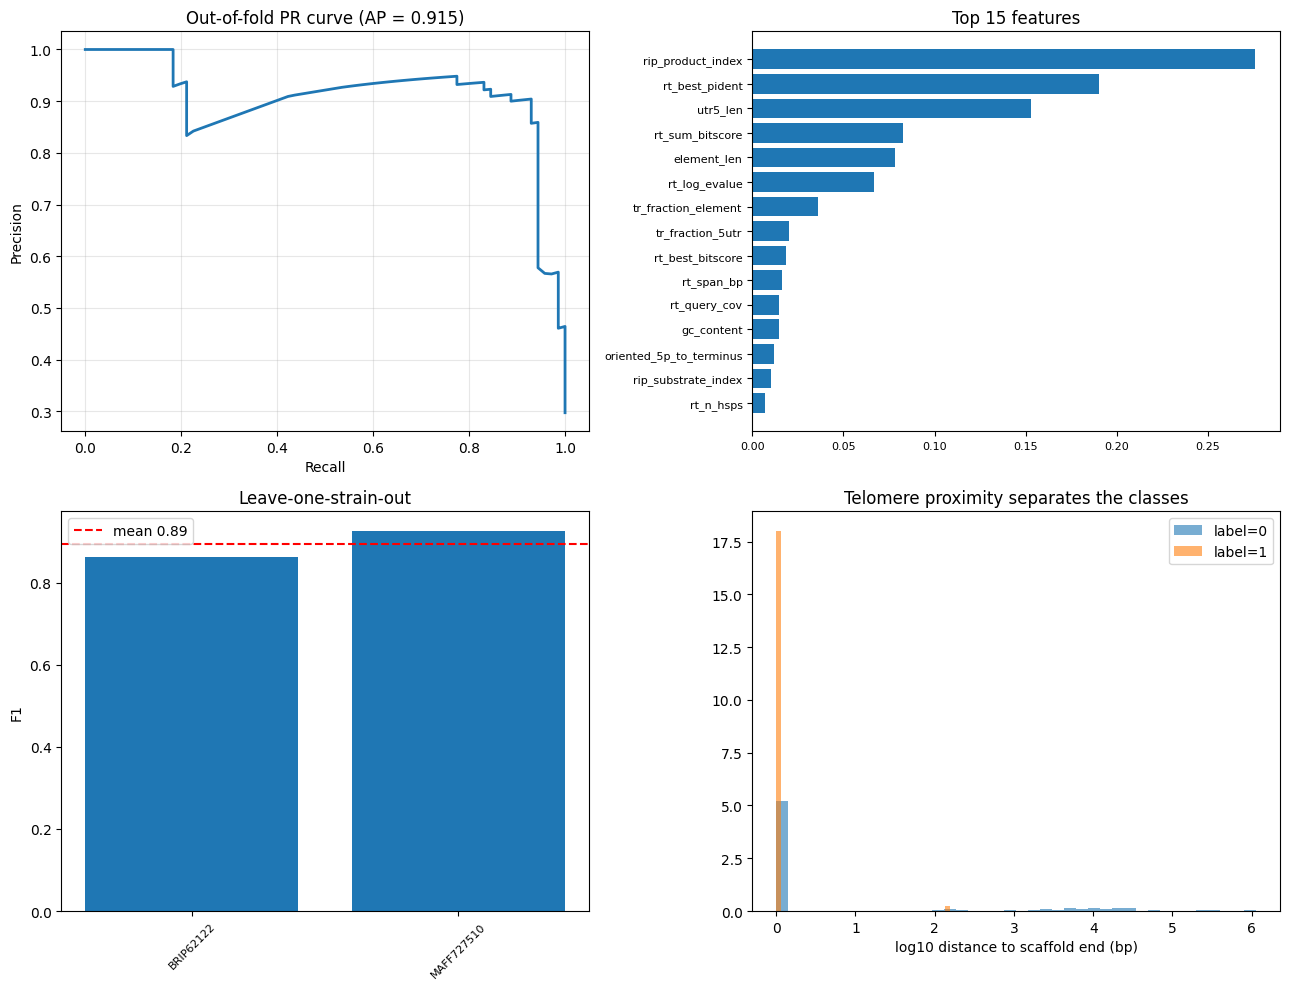

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(2, 2, figsize=(13, 10))

p, r, _ = precision_recall_curve(data.label, data.oof_score)
ap = average_precision_score(data.label, data.oof_score)
ax[0,0].plot(r, p, lw=2); ax[0,0].set_xlabel("Recall"); ax[0,0].set_ylabel("Precision")
ax[0,0].set_title(f"Out-of-fold PR curve (AP = {ap:.3f})"); ax[0,0].grid(alpha=.3)

top = imp.head(15).iloc[::-1]
ax[0,1].barh(top.feature, top.importance)
ax[0,1].set_title("Top 15 features"); ax[0,1].tick_params(labelsize=8)

ax[1,0].bar(loso.held_out_strain, loso.f1)
ax[1,0].axhline(loso.f1.mean(), ls="--", c="r", label=f"mean {loso.f1.mean():.2f}")
ax[1,0].set_ylabel("F1"); ax[1,0].set_title("Leave-one-strain-out")
ax[1,0].tick_params(axis="x", rotation=45, labelsize=8); ax[1,0].legend()

for lbl, sub in data.groupby("label"):
    ax[1,1].hist(np.log10(sub.dist_to_scaffold_end.clip(lower=1)), bins=40,
                 alpha=.6, density=True, label=f"label={lbl}")
ax[1,1].set_xlabel("log10 distance to scaffold end (bp)")
ax[1,1].set_title("Telomere proximity separates the classes"); ax[1,1].legend()

plt.tight_layout(); plt.savefig("results/figures/model_performance.png", dpi=200)
plt.show()

In [28]:
!cd /content && zip -qr foter_results.zip \
    foter_detector/results foter_detector/models foter_detector/src \
    foter_detector/data/published foter_detector/data/reference
print("wrote /content/foter_results.zip")
from google.colab import files
files.download('/content/foter_results.zip')

wrote /content/foter_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>